# Solution IA InnoMoov — Maintenance prédictive par prédiction de RUL

## Objectif

Ce notebook propose une solution IA adaptée au contexte **InnoMoov** pour anticiper la dégradation des équipements critiques.

L’objectif est de prédire la **RUL — Remaining Useful Life**, c’est-à-dire le nombre de cycles de fonctionnement restants avant qu’un équipement atteigne un état critique.

Dans le projet InnoMoov, cette solution peut être intégrée à l’architecture Industrie 4.0 existante :

```text
Capteurs machines → OPC UA / MQTT → MES / UNS → Modèle IA RUL → Dashboard maintenance → Décision opérationnelle
```

## Problématique métier

> À partir de l’historique des signaux capteurs d’une machine, peut-on estimer sa durée de vie restante afin de planifier la maintenance avant la panne ?

## Valeur pour InnoMoov

- réduire les arrêts non planifiés ;
- améliorer la disponibilité des équipements ;
- prioriser les interventions de maintenance ;
- mieux planifier les pièces de rechange ;
- améliorer le TRS ;
- transformer les données machines en décisions opérationnelles.

---
## 1. Chargement des bibliothèques et configuration du projet

In [2]:
from pathlib import Path
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------
# Configuration visuelle InnoMoov
# ------------------------------------------------------------------
INNO_TEAL = "#00796B"
INNO_DARK = "#102A43"
INNO_ORANGE = "#F26A1B"
INNO_GREEN = "#2E8B57"
INNO_RED = "#D62828"
INNO_GRAY = "#EEF2F3"

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.facecolor"] = "#FAFAFA"
plt.rcParams["axes.edgecolor"] = INNO_DARK
plt.rcParams["axes.labelcolor"] = INNO_DARK
plt.rcParams["xtick.color"] = INNO_DARK
plt.rcParams["ytick.color"] = INNO_DARK
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14

# ------------------------------------------------------------------
# Détection du chemin projet
# ------------------------------------------------------------------
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"
MODELS_PATH = PROJECT_ROOT / "models"
REPORTS_PATH = PROJECT_ROOT / "reports"
FIGURES_PATH = REPORTS_PATH / "figures"

for folder in [PROCESSED_DATA_PATH, MODELS_PATH, FIGURES_PATH]:
    folder.mkdir(parents=True, exist_ok=True)

print("Racine projet       :", PROJECT_ROOT)
print("Dossier data/raw    :", RAW_DATA_PATH)
print("Dossier models      :", MODELS_PATH)
print("Dossier figures     :", FIGURES_PATH)

Racine projet       : c:\Users\ghood\Desktop\MaintenancePredictive_Moteurs
Dossier data/raw    : c:\Users\ghood\Desktop\MaintenancePredictive_Moteurs\data\raw
Dossier models      : c:\Users\ghood\Desktop\MaintenancePredictive_Moteurs\models
Dossier figures     : c:\Users\ghood\Desktop\MaintenancePredictive_Moteurs\reports\figures


---
## 2. Chargement du dataset NASA C-MAPSS

Le dataset contient des historiques de fonctionnement de moteurs.  
Chaque ligne correspond à un cycle de fonctionnement d’un moteur avec :

- un identifiant moteur ;
- un numéro de cycle ;
- des conditions opérationnelles ;
- des signaux capteurs ;
- une trajectoire de dégradation.

Dans ce notebook, on travaille sur le sous-ensemble **FD001**, qui est un bon point de départ pour construire une solution RUL claire et industrialisable.

In [3]:
# ------------------------------------------------------------------
# Fichiers FD001
# ------------------------------------------------------------------
DATASET_ID = "FD001"

train_path = RAW_DATA_PATH / f"train_{DATASET_ID}.txt"
test_path = RAW_DATA_PATH / f"test_{DATASET_ID}.txt"
rul_path = RAW_DATA_PATH / f"RUL_{DATASET_ID}.txt"

columns = (
    ["engine_id", "cycle"]
    + [f"setting_{i}" for i in range(1, 4)]
    + [f"sensor_{i}" for i in range(1, 22)]
)

if not train_path.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {train_path}\n"
        "Place les fichiers NASA C-MAPSS dans data/raw/ puis relance le notebook."
    )

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=columns)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=columns)
rul_df = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])

print("Train shape :", train_df.shape)
print("Test shape  :", test_df.shape)
print("RUL shape   :", rul_df.shape)

display(train_df.head())

Train shape : (20631, 26)
Test shape  : (13096, 26)
RUL shape   : (100, 1)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Le chargement confirme que le jeu **FD001** contient **20 631 cycles d’entraînement**, **13 096 cycles de test** et **100 moteurs** avec une RUL connue.  
Pour InnoMoov, cela représente un historique industriel exploitable : chaque ligne correspond à un instant de fonctionnement d’un équipement, avec ses conditions opératoires et ses signaux capteurs. L’objectif sera donc d’apprendre l’évolution progressive de la dégradation, et non de se limiter à une alerte ponctuelle.

### Lecture métier

Chaque moteur est observé cycle après cycle jusqu’à un état final.  
Dans le contexte InnoMoov, on peut assimiler ces moteurs à des équipements critiques de l’usine : machines d’assemblage, moteurs de convoyeurs, modules robotisés ou sous-systèmes embarqués.

L’objectif est d’apprendre la dynamique de dégradation à partir des signaux capteurs.

---
## 3. Compréhension de la structure des données

In [4]:
print("Nombre de moteurs dans le train :", train_df["engine_id"].nunique())
print("Nombre total de cycles observés :", train_df["cycle"].count())
print("Nombre de variables :", train_df.shape[1])

missing_values = train_df.isnull().sum()
print("Nombre total de valeurs manquantes :", missing_values.sum())

display(train_df.describe().T.head(12))

Nombre de moteurs dans le train : 100
Nombre total de cycles observés : 20631
Nombre de variables : 26
Nombre total de valeurs manquantes : 0


,count,mean,std,min,25%,50%,75%,max
engine_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.00,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.00,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.00,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.00,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.00,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.67,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.64,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.10,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.04,1414.5550,1441.4900
sensor_5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.62,14.6200,14.6200


Le dataset est propre : aucune valeur manquante n’est détectée. C’est un point favorable pour construire rapidement une première solution IA.  
En revanche, certaines variables sont constantes ou quasi constantes, ce qui indique qu’elles n’apporteront pas d’information utile au modèle. Une étape de sélection de capteurs est donc nécessaire avant l’entraînement.

---
## 4. Analyse de la durée de vie des équipements

Chaque moteur possède une durée de vie différente.  
Cette variabilité est importante : le modèle doit apprendre des trajectoires de dégradation, et non mémoriser une durée fixe.

,engine_id,max_cycle
count,100.000000,100.000000
mean,50.500000,206.310000
std,29.011492,46.342749
min,1.000000,128.000000
25%,25.750000,177.000000
50%,50.500000,199.000000
75%,75.250000,229.250000
max,100.000000,362.000000


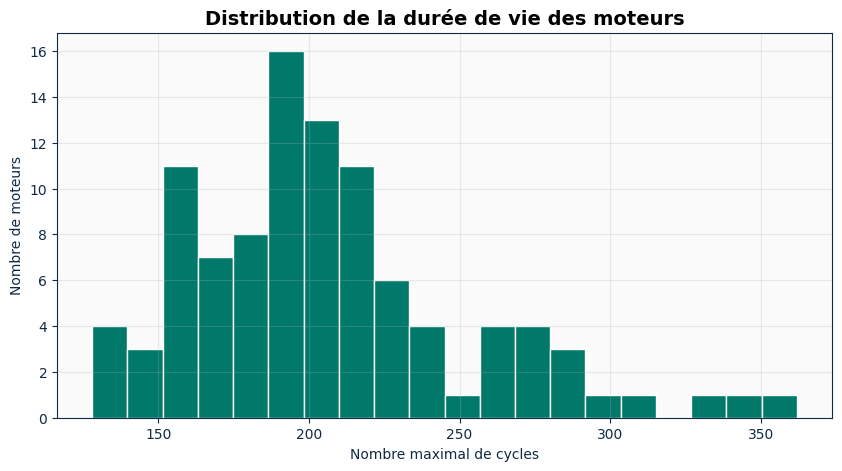

In [5]:
engine_life = train_df.groupby("engine_id")["cycle"].max().reset_index()
engine_life.columns = ["engine_id", "max_cycle"]

display(engine_life.describe())

plt.figure(figsize=(10, 5))
plt.hist(engine_life["max_cycle"], bins=20, color=INNO_TEAL, edgecolor="white")
plt.title("Distribution de la durée de vie des moteurs")
plt.xlabel("Nombre maximal de cycles")
plt.ylabel("Nombre de moteurs")
plt.grid(alpha=0.25)
plt.show()

Les moteurs n’ont pas tous la même durée de vie : certains atteignent l’état critique après **128 cycles**, tandis que d’autres vont jusqu’à **362 cycles**.  
Cette variabilité est importante : elle montre que la maintenance ne peut pas être planifiée avec une règle fixe. Un modèle IA est pertinent car il peut adapter la prédiction à la trajectoire réelle de chaque équipement.

---
## 5. Construction de la variable cible RUL

La cible du modèle est la **RUL — Remaining Useful Life**.

\[
RUL = cycle_{max} - cycle_{actuel}
\]

Une RUL élevée signifie que l’équipement est encore loin de son état critique.  
Une RUL faible signifie que l’équipement approche de la panne ou de la fin de vie utile.

In [6]:
max_cycle_per_engine = train_df.groupby("engine_id")["cycle"].max().reset_index()
max_cycle_per_engine.columns = ["engine_id", "max_cycle"]

train_df = train_df.merge(max_cycle_per_engine, on="engine_id", how="left")
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]
train_df.drop(columns=["max_cycle"], inplace=True)

display(train_df[["engine_id", "cycle", "RUL"]].head())
display(train_df[["engine_id", "cycle", "RUL"]].tail())

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


,engine_id,cycle,RUL
20626,100,196,4
20627,100,197,3
20628,100,198,2
20629,100,199,1
20630,100,200,0


La RUL diminue naturellement au fil des cycles. Au début, le moteur possède encore une durée de vie élevée ; à la fin, la RUL se rapproche de **0**, ce qui correspond à un état critique.  
Pour InnoMoov, cette variable est directement exploitable dans un dashboard maintenance : elle permet de passer d’un simple état “normal / panne” à une estimation du temps restant avant intervention.

### Plafonnement de la RUL

Dans beaucoup d’approches RUL, on plafonne la cible.  
Cela évite de demander au modèle de distinguer trop finement les équipements encore très éloignés de la panne.

Ici, on considère qu’au-delà de **125 cycles**, l’équipement est dans une zone saine.  
La prédiction devient surtout critique lorsque la RUL descend sous certains seuils.

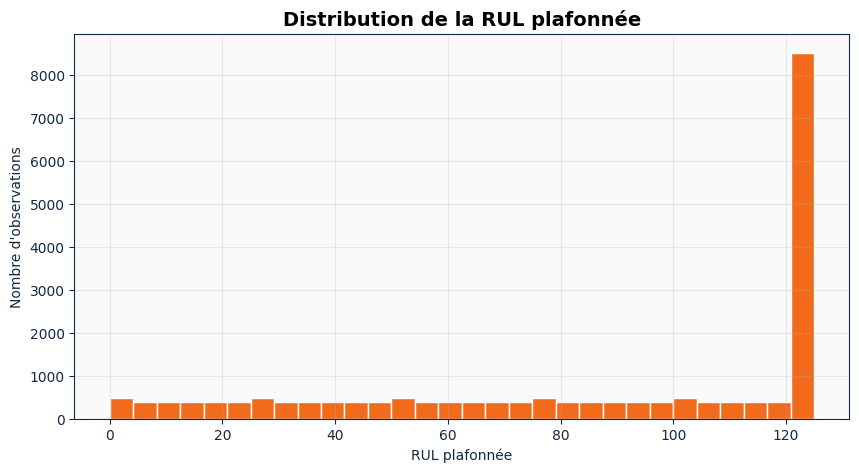

In [7]:
RUL_MAX = 125
train_df["RUL_clipped"] = train_df["RUL"].clip(upper=RUL_MAX)

plt.figure(figsize=(10, 5))
plt.hist(train_df["RUL_clipped"], bins=30, color=INNO_ORANGE, edgecolor="white")
plt.title("Distribution de la RUL plafonnée")
plt.xlabel("RUL plafonnée")
plt.ylabel("Nombre d'observations")
plt.grid(alpha=0.25)
plt.show()

Le plafonnement à **125 cycles** évite de surinterpréter les équipements encore très éloignés de la panne.  
D’un point de vue industriel, l’enjeu principal n’est pas de savoir si une machine a 180 ou 220 cycles restants, mais de détecter correctement les zones critiques lorsque la RUL devient faible.

---
## 6. Visualisation de trajectoires de dégradation

Cette visualisation permet de suivre la RUL de quelques moteurs au fil des cycles.  
Elle montre l’idée métier principale : plus les cycles avancent, plus la durée de vie restante diminue.

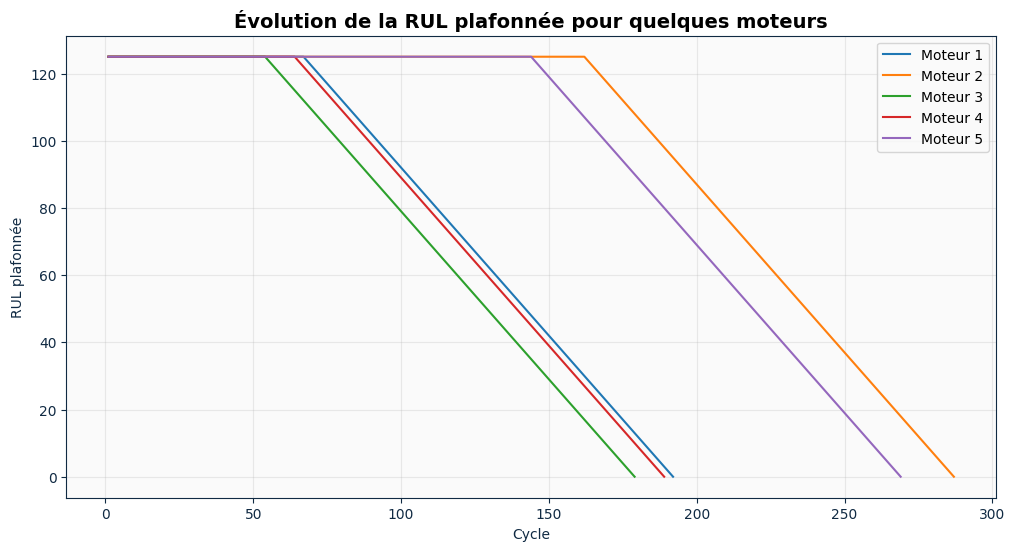

In [8]:
sample_engines = [1, 2, 3, 4, 5]

plt.figure(figsize=(12, 6))
for engine_id in sample_engines:
    engine_data = train_df[train_df["engine_id"] == engine_id]
    plt.plot(engine_data["cycle"], engine_data["RUL_clipped"], label=f"Moteur {engine_id}")

plt.title("Évolution de la RUL plafonnée pour quelques moteurs")
plt.xlabel("Cycle")
plt.ylabel("RUL plafonnée")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

Les trajectoires montrent une dégradation progressive : plus les cycles avancent, plus la RUL diminue.  
Cette logique est très proche d’un cas réel chez InnoMoov : un convoyeur, un module robotisé ou une machine d’assemblage ne tombe pas toujours en panne brutalement ; ses signaux se dégradent souvent avant l’arrêt.

---
## 7. Analyse des capteurs et sélection des variables

Certains capteurs peuvent être constants ou peu informatifs.  
Les conserver peut bruiter le modèle et augmenter inutilement la complexité.

On identifie donc :

- les capteurs à faible variance ;
- les capteurs fortement corrélés à la RUL ;
- les variables pertinentes pour la modélisation.

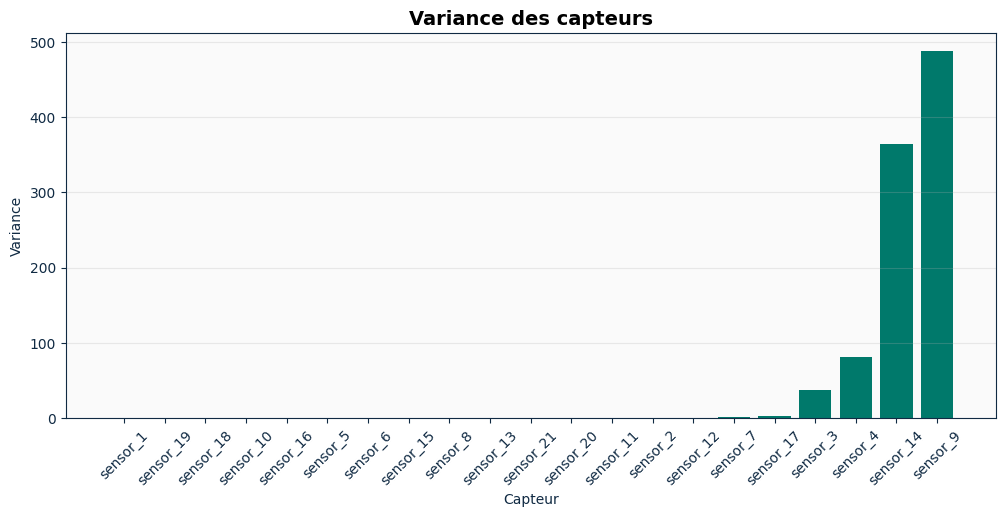

Capteurs à très faible variance : ['sensor_1', 'sensor_19', 'sensor_18', 'sensor_10', 'sensor_16', 'sensor_5']


In [9]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
setting_cols = [f"setting_{i}" for i in range(1, 4)]

# Variance des capteurs
sensor_variance = train_df[sensor_cols].var().sort_values()

plt.figure(figsize=(12, 5))
plt.bar(sensor_variance.index, sensor_variance.values, color=INNO_TEAL)
plt.title("Variance des capteurs")
plt.xlabel("Capteur")
plt.ylabel("Variance")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.show()

low_variance_sensors = sensor_variance[sensor_variance < 1e-6].index.tolist()
print("Capteurs à très faible variance :", low_variance_sensors)

Les capteurs à très faible variance, comme `sensor_1`, `sensor_5`, `sensor_10`, `sensor_16`, `sensor_18` et `sensor_19`, varient trop peu pour aider le modèle.  
Les conserver augmenterait la complexité sans améliorer la prédiction. Leur suppression permet d’obtenir un modèle plus léger, plus robuste et plus facilement déployable.

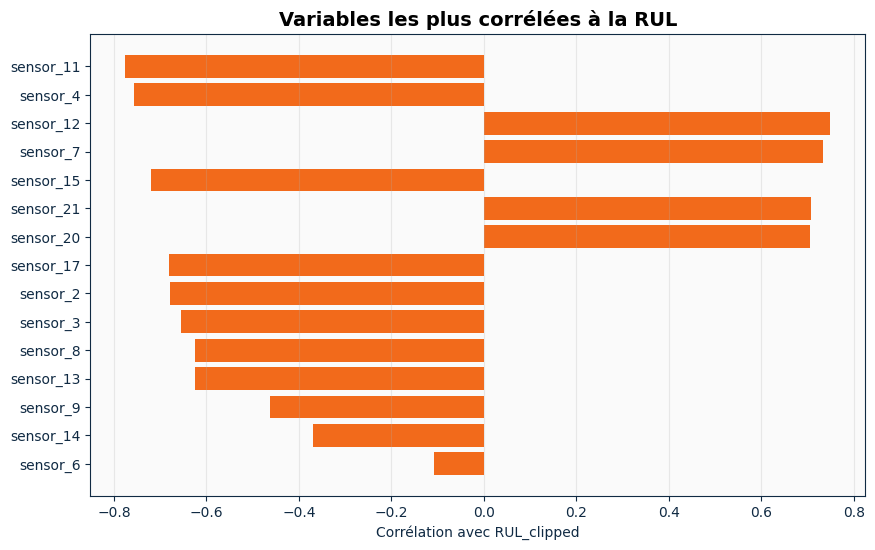

sensor_11   -0.775230
sensor_4    -0.757157
sensor_12    0.748870
sensor_7     0.733021
sensor_15   -0.720858
sensor_21    0.707334
sensor_20    0.704626
sensor_17   -0.680829
sensor_2    -0.678458
sensor_3    -0.655030
sensor_8    -0.624568
sensor_13   -0.624034
sensor_9    -0.462151
sensor_14   -0.369753
sensor_6    -0.108289
Name: RUL_clipped, dtype: float64

In [10]:
# Corrélation avec la RUL plafonnée
corr_with_rul = train_df[sensor_cols + setting_cols + ["RUL_clipped"]].corr()["RUL_clipped"]
corr_with_rul = corr_with_rul.drop("RUL_clipped").sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(corr_with_rul.index[:15][::-1], corr_with_rul.values[:15][::-1], color=INNO_ORANGE)
plt.title("Variables les plus corrélées à la RUL")
plt.xlabel("Corrélation avec RUL_clipped")
plt.grid(axis="x", alpha=0.25)
plt.show()

display(corr_with_rul.head(15))

Plusieurs capteurs sont fortement liés à la RUL, notamment `sensor_11`, `sensor_4`, `sensor_12`, `sensor_7`, `sensor_15`, `sensor_21` et `sensor_20`.  
Ces variables sont de bons indicateurs de dégradation. Dans un contexte InnoMoov, elles correspondraient aux signaux à surveiller en priorité dans le MES ou le dashboard maintenance.

### Variables retenues

On retire les colonnes non informatives et on conserve les conditions opérationnelles + les capteurs utiles.

Dans une vraie usine InnoMoov, cette étape serait réalisée avec les experts maintenance pour valider que les capteurs retenus ont du sens métier.

In [11]:
# Liste couramment retirée dans FD001 car peu informative ou quasi constante
default_drop_sensors = [
    "sensor_1", "sensor_5", "sensor_6", "sensor_10",
    "sensor_16", "sensor_18", "sensor_19"
]

drop_sensors = [c for c in default_drop_sensors if c in train_df.columns]
feature_cols = setting_cols + [c for c in sensor_cols if c not in drop_sensors]

print("Capteurs supprimés :", drop_sensors)
print("Nombre de variables retenues :", len(feature_cols))
print(feature_cols)

Capteurs supprimés : ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Nombre de variables retenues : 17
['setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


Après nettoyage, **17 variables** sont retenues pour la modélisation.  
Ce compromis est intéressant : on garde les signaux les plus utiles tout en supprimant les capteurs peu informatifs. Cela facilite aussi une future intégration dans une application Streamlit ou un service IA connecté au MES.

---
## 8. Préparation train / validation sans fuite temporelle

Pour éviter une fuite de données, on sépare les moteurs par identifiant.  
Ainsi, les cycles d’un même moteur ne se retrouvent pas à la fois dans l’entraînement et dans la validation.

C’est plus réaliste industriellement : le modèle doit généraliser à de nouveaux équipements.

In [12]:
from sklearn.model_selection import train_test_split

engine_ids = train_df["engine_id"].unique()

train_engine_ids, val_engine_ids = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_data = train_df[train_df["engine_id"].isin(train_engine_ids)].copy()
val_data = train_df[train_df["engine_id"].isin(val_engine_ids)].copy()

print("Moteurs train :", len(train_engine_ids))
print("Moteurs validation :", len(val_engine_ids))
print("Train data shape :", train_data.shape)
print("Validation data shape :", val_data.shape)

Moteurs train : 80
Moteurs validation : 20
Train data shape : (16561, 28)
Validation data shape : (4070, 28)


La séparation est faite par moteur : **80 moteurs** servent à l’entraînement et **20 moteurs** à la validation.  
C’est plus réaliste qu’un split aléatoire ligne par ligne, car le modèle doit être capable de prédire la RUL d’équipements jamais vus pendant l’apprentissage.

---
## 9. Normalisation des variables

Les modèles de Deep Learning sont sensibles aux échelles des variables.  
On ajuste le scaler uniquement sur les données d’entraînement, puis on l’applique à la validation.

Cela évite d’utiliser des informations du jeu de validation pendant l’apprentissage.

In [13]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

train_data_scaled = train_data.copy()
val_data_scaled = val_data.copy()

train_data_scaled[feature_cols] = scaler.fit_transform(train_data[feature_cols])
val_data_scaled[feature_cols] = scaler.transform(val_data[feature_cols])

scaler_path = MODELS_PATH / "innomoov_rul_scaler.joblib"
joblib.dump(scaler, scaler_path)

print("Scaler sauvegardé :", scaler_path)
display(train_data_scaled[feature_cols].head())

Scaler sauvegardé : c:\Users\ghood\Desktop\MaintenancePredictive_Moteurs\models\innomoov_rul_scaler.joblib


,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
192,-0.818512,2.043793,0.0,-1.581191,-1.092662,-1.963014,1.318090,-1.221017,-0.471297,-2.294365,1.242127,-0.500147,-0.315944,-1.373754,-1.426246,0.678684,1.564436
193,1.966124,-1.031739,0.0,-1.721722,-0.565155,-1.756664,1.591518,-1.645675,-0.621789,-1.127747,1.745551,-1.615806,-0.654442,-0.675217,-0.779529,1.345844,1.098895
194,0.824880,1.018616,0.0,-2.263772,-0.356453,-1.106382,2.013053,-0.796358,-0.492481,-1.203012,1.582278,-1.476349,-0.169925,-1.648369,-1.426246,1.623827,1.252524
195,1.600926,-1.373465,0.0,-2.002785,-1.041719,-1.427619,0.999091,-1.645675,-0.326102,-1.654606,1.459824,-2.313093,-0.177072,-1.072476,-1.426246,1.735021,1.975974
196,0.231433,1.360341,0.0,-1.902406,-1.883102,-0.709298,1.990267,-0.937911,-0.319923,-1.090114,1.160491,-2.173636,-0.369552,-1.475068,-2.072963,2.013004,1.237627


La normalisation est appliquée uniquement à partir des données d’entraînement, puis réutilisée sur la validation.  
Cette méthode évite la fuite de données et prépare le modèle à un usage réel, où les nouvelles mesures devront être transformées exactement avec le même scaler.

---
## 10. Création des séquences temporelles

Une panne n’apparaît pas toujours dans une mesure isolée.  
Elle se manifeste souvent par une évolution progressive des signaux.

Le modèle utilise donc des fenêtres de **30 cycles consécutifs**.  
La cible associée à chaque fenêtre est la RUL du dernier cycle de la séquence.

In [14]:
SEQUENCE_LENGTH = 30

def create_sequences(df, feature_cols, target_col="RUL_clipped", sequence_length=30):
    """
    Crée des séquences temporelles par moteur.

    Chaque séquence contient sequence_length cycles consécutifs.
    La cible correspond à la RUL du dernier cycle.
    """
    X_sequences = []
    y_sequences = []
    engine_sequence_ids = []

    for engine_id in df["engine_id"].unique():
        engine_data = df[df["engine_id"] == engine_id].sort_values("cycle")
        feature_values = engine_data[feature_cols].values
        target_values = engine_data[target_col].values

        if len(engine_data) < sequence_length:
            continue

        for start in range(0, len(engine_data) - sequence_length + 1):
            end = start + sequence_length
            X_sequences.append(feature_values[start:end])
            y_sequences.append(target_values[end - 1])
            engine_sequence_ids.append(engine_id)

    return np.array(X_sequences), np.array(y_sequences), np.array(engine_sequence_ids)

X_train, y_train, train_seq_engine_ids = create_sequences(
    train_data_scaled,
    feature_cols,
    target_col="RUL_clipped",
    sequence_length=SEQUENCE_LENGTH
)

X_val, y_val, val_seq_engine_ids = create_sequences(
    val_data_scaled,
    feature_cols,
    target_col="RUL_clipped",
    sequence_length=SEQUENCE_LENGTH
)

print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_val   :", X_val.shape)
print("y_val   :", y_val.shape)

X_train : (14241, 30, 17)
y_train : (14241,)
X_val   : (3490, 30, 17)
y_val   : (3490,)


Les séquences créées ont la forme **30 cycles × 17 variables**.  
Le modèle ne regarde donc pas une mesure isolée, mais une fenêtre temporelle récente de l’équipement. C’est essentiel pour la maintenance prédictive, car la dégradation est souvent visible dans l’évolution des signaux.

---
## 11. Modèles IA testés

On compare plusieurs modèles :

1. **MLP baseline** : modèle dense simple, utilisé comme référence.
2. **CNN 1D** : modèle adapté aux séquences de capteurs, capable de détecter des motifs locaux de dégradation.
3. **GRU** : modèle récurrent plus léger que LSTM, utile pour apprendre les dépendances temporelles.

Pour InnoMoov, l’objectif n’est pas seulement d’avoir le meilleur score, mais un modèle suffisamment performant, stable et intégrable dans une application de maintenance.

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

input_shape = (X_train.shape[1], X_train.shape[2])

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

print("TensorFlow version :", tf.__version__)
print("Input shape :", input_shape)

TensorFlow version : 2.10.1
Input shape : (30, 17)


In [16]:
def build_mlp_baseline(input_shape):
    model = models.Sequential([
        layers.Input(shape=(input_shape[0] * input_shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )
    return model


def build_cnn1d_model(input_shape, filters=64, kernel_size=3, dense_units=64, dropout=0.2):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(filters=filters, kernel_size=kernel_size, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(filters=filters * 2, kernel_size=kernel_size, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )
    return model


def build_gru_model(input_shape, units=64, dense_units=64, dropout=0.2):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.GRU(units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )
    return model

---
## 12. Entraînement des modèles

Pour limiter le temps de calcul, les modèles sont entraînés avec EarlyStopping.  
Le nombre d’epochs peut être augmenté si l’environnement d’exécution le permet.

In [17]:
def train_model(model, X_train_input, y_train, X_val_input, y_val, model_name, epochs=60, batch_size=64):
    print("=" * 80)
    print("Entraînement :", model_name)

    history = model.fit(
        X_train_input,
        y_train,
        validation_data=(X_val_input, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=1
    )

    history_df = pd.DataFrame(history.history)
    best_idx = history_df["val_mae"].idxmin()

    result = {
        "model_name": model_name,
        "model": model,
        "history": history_df,
        "best_epoch": int(best_idx + 1),
        "val_loss": float(history_df.loc[best_idx, "val_loss"]),
        "val_mae": float(history_df.loc[best_idx, "val_mae"]),
        "val_rmse": float(history_df.loc[best_idx, "val_rmse"]),
    }

    print("Meilleure epoch :", result["best_epoch"])
    print("Validation MAE  :", round(result["val_mae"], 4))
    print("Validation RMSE :", round(result["val_rmse"], 4))

    return result

In [18]:
# ---------------------------
# MLP baseline
# ---------------------------
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

mlp_model = build_mlp_baseline(input_shape)
mlp_result = train_model(
    mlp_model,
    X_train_flat,
    y_train,
    X_val_flat,
    y_val,
    model_name="MLP baseline"
)

Entraînement : MLP baseline
Epoch 1/60
223/223 [==============================] - 1s 3ms/step - loss: 2396.4275 - mae: 38.5784 - rmse: 48.9533 - val_loss: 997.6736 - val_mae: 24.3201 - val_rmse: 31.5860
Epoch 2/60
223/223 [==============================] - 1s 3ms/step - loss: 950.2321 - mae: 24.0986 - rmse: 30.8258 - val_loss: 371.8660 - val_mae: 14.7474 - val_rmse: 19.2838
Epoch 3/60
223/223 [==============================] - 1s 3ms/step - loss: 498.8657 - mae: 17.3128 - rmse: 22.3353 - val_loss: 264.3711 - val_mae: 12.4649 - val_rmse: 16.2595
Epoch 4/60
223/223 [==============================] - 1s 3ms/step - loss: 379.5098 - mae: 15.1350 - rmse: 19.4810 - val_loss: 273.8531 - val_mae: 12.9157 - val_rmse: 16.5485
Epoch 5/60
223/223 [==============================] - 1s 3ms/step - loss: 349.3390 - mae: 14.4230 - rmse: 18.6906 - val_loss: 226.8831 - val_mae: 11.6125 - val_rmse: 15.0626
Epoch 6/60
223/223 [==============================] - 1s 3ms/step - loss: 314.1015 - mae: 13.6857 - r

In [19]:
# ---------------------------
# CNN 1D
# ---------------------------
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

cnn_model = build_cnn1d_model(input_shape, filters=64, kernel_size=3, dense_units=64, dropout=0.2)
cnn_result = train_model(
    cnn_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="CNN 1D"
)

Entraînement : CNN 1D
Epoch 1/60
223/223 [==============================] - 2s 7ms/step - loss: 2479.7405 - mae: 36.9156 - rmse: 49.7970 - val_loss: 845.0923 - val_mae: 20.9454 - val_rmse: 29.0705
Epoch 2/60
223/223 [==============================] - 1s 6ms/step - loss: 443.4299 - mae: 16.6610 - rmse: 21.0578 - val_loss: 292.0889 - val_mae: 13.3493 - val_rmse: 17.0906
Epoch 3/60
223/223 [==============================] - 1s 6ms/step - loss: 366.0703 - mae: 14.9680 - rmse: 19.1330 - val_loss: 450.9530 - val_mae: 18.1740 - val_rmse: 21.2357
Epoch 4/60
223/223 [==============================] - 1s 6ms/step - loss: 323.4567 - mae: 14.0896 - rmse: 17.9849 - val_loss: 453.0908 - val_mae: 18.4204 - val_rmse: 21.2859
Epoch 5/60
223/223 [==============================] - 1s 6ms/step - loss: 288.1500 - mae: 13.2122 - rmse: 16.9750 - val_loss: 429.6792 - val_mae: 17.1363 - val_rmse: 20.7287
Epoch 6/60
223/223 [==============================] - 1s 6ms/step - loss: 257.1577 - mae: 12.4310 - rmse: 1

In [20]:
# ---------------------------
# GRU
# ---------------------------
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

gru_model = build_gru_model(input_shape, units=64, dense_units=64, dropout=0.2)
gru_result = train_model(
    gru_model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name="GRU"
)

Entraînement : GRU
Epoch 1/60
223/223 [==============================] - 4s 13ms/step - loss: 3565.7837 - mae: 47.7334 - rmse: 59.7142 - val_loss: 760.5280 - val_mae: 22.4685 - val_rmse: 27.5777
Epoch 2/60
223/223 [==============================] - 3s 12ms/step - loss: 754.5886 - mae: 21.8995 - rmse: 27.4698 - val_loss: 636.0920 - val_mae: 19.6959 - val_rmse: 25.2209
Epoch 3/60
223/223 [==============================] - 2s 11ms/step - loss: 616.8340 - mae: 19.7723 - rmse: 24.8361 - val_loss: 328.3949 - val_mae: 14.5155 - val_rmse: 18.1217
Epoch 4/60
223/223 [==============================] - 2s 11ms/step - loss: 505.8626 - mae: 17.7933 - rmse: 22.4914 - val_loss: 288.2970 - val_mae: 13.4382 - val_rmse: 16.9793
Epoch 5/60
223/223 [==============================] - 2s 11ms/step - loss: 493.5430 - mae: 17.4342 - rmse: 22.2158 - val_loss: 286.3513 - val_mae: 13.1842 - val_rmse: 16.9219
Epoch 6/60
223/223 [==============================] - 2s 11ms/step - loss: 476.7866 - mae: 17.1319 - rmse

---
## 13. Comparaison des modèles

Le modèle retenu est celui qui minimise la **MAE** sur validation, car la MAE correspond directement à l’erreur moyenne en nombre de cycles.

Une MAE de 12 signifie par exemple que le modèle se trompe en moyenne d’environ 12 cycles sur la RUL.

,Modèle,Best epoch,MAE validation,RMSE validation,Loss validation
0,GRU,20,9.4934,13.0509,170.3260
1,MLP baseline,39,10.0498,13.2895,176.6100
2,CNN 1D,2,13.3493,17.0906,292.0889


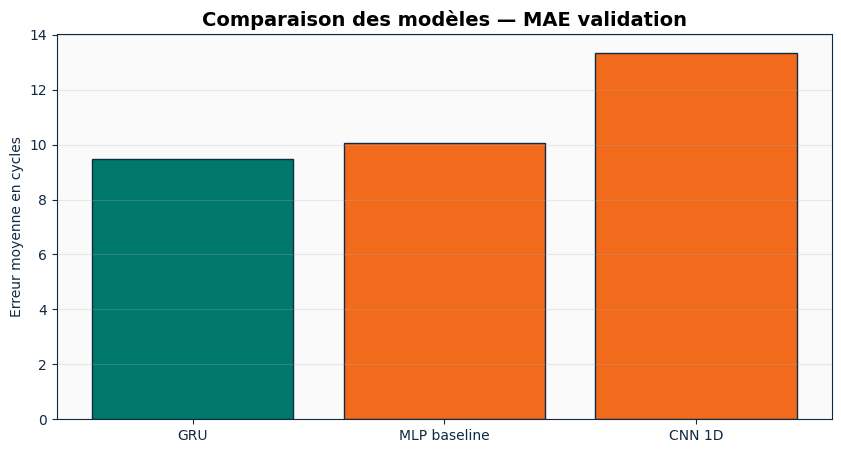

Meilleur modèle retenu : GRU


In [21]:
results = [mlp_result, cnn_result, gru_result]

comparison_df = pd.DataFrame([
    {
        "Modèle": r["model_name"],
        "Best epoch": r["best_epoch"],
        "MAE validation": r["val_mae"],
        "RMSE validation": r["val_rmse"],
        "Loss validation": r["val_loss"],
    }
    for r in results
]).sort_values("MAE validation").reset_index(drop=True)

display(comparison_df.round(4))

plt.figure(figsize=(10, 5))
colors = [INNO_TEAL if i == 0 else INNO_ORANGE for i in range(len(comparison_df))]
plt.bar(comparison_df["Modèle"], comparison_df["MAE validation"], color=colors, edgecolor=INNO_DARK)
plt.title("Comparaison des modèles — MAE validation")
plt.ylabel("Erreur moyenne en cycles")
plt.grid(axis="y", alpha=0.25)
plt.show()

best_model_name = comparison_df.loc[0, "Modèle"]
print("Meilleur modèle retenu :", best_model_name)

Le **GRU** obtient la meilleure performance avec une **MAE validation de 9,49 cycles**, devant le MLP baseline (**10,05 cycles**) et le CNN 1D (**13,35 cycles**).  
Le choix du GRU est cohérent avec le problème : il est conçu pour exploiter les dépendances temporelles dans les séquences de capteurs. Pour InnoMoov, cela signifie que le modèle apprend mieux la dynamique de dégradation qu’un modèle plus simple.

---
## 14. Évaluation finale du meilleur modèle

Dans cette exécution, le modèle retenu est le **GRU**, avec :

- **MAE : 10,02 cycles** ;
- **RMSE : 12,91 cycles** ;
- **R² : 0,9044**.

Les prédictions sont plafonnées entre 0 et 125 cycles pour rester cohérentes avec la cible utilisée.

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_result = next(r for r in results if r["model_name"] == best_model_name)
best_model = best_result["model"]

if best_model_name == "MLP baseline":
    y_val_pred = best_model.predict(X_val_flat).flatten()
else:
    y_val_pred = best_model.predict(X_val).flatten()

y_val_pred_clipped = np.clip(y_val_pred, 0, RUL_MAX)

final_mae = mean_absolute_error(y_val, y_val_pred_clipped)
final_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_clipped))
final_r2 = r2_score(y_val, y_val_pred_clipped)

print("Évaluation finale du modèle retenu")
print("Modèle :", best_model_name)
print("MAE  :", round(final_mae, 4), "cycles")
print("RMSE :", round(final_rmse, 4), "cycles")
print("R²   :", round(final_r2, 4))

110/110 [==============================] - 1s 3ms/step
Évaluation finale du modèle retenu
Modèle : GRU
MAE  : 10.0164 cycles
RMSE : 12.908 cycles
R²   : 0.9044


Le modèle retenu est le **GRU**. Il obtient une **MAE de 10,02 cycles**, un **RMSE de 12,91 cycles** et un **R² de 0,9044**.  
Autrement dit, le modèle explique environ **90 % de la variabilité** de la RUL et se trompe en moyenne d’environ **10 cycles**. Pour une première solution de maintenance prédictive, ce niveau de performance est très satisfaisant.

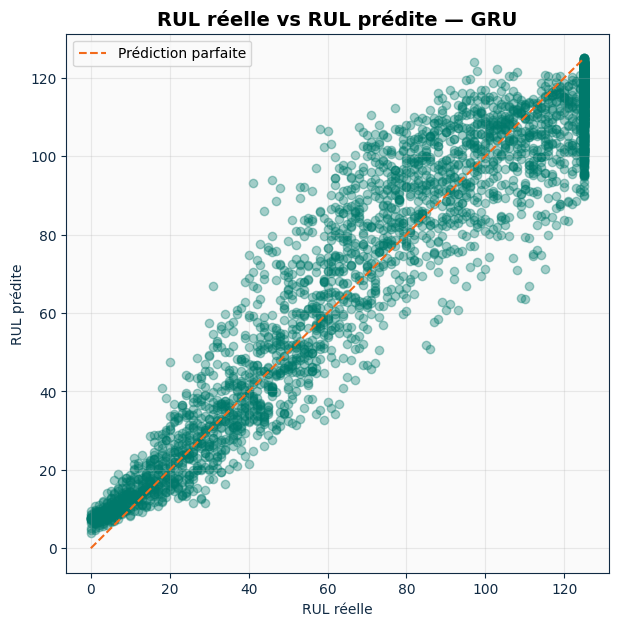

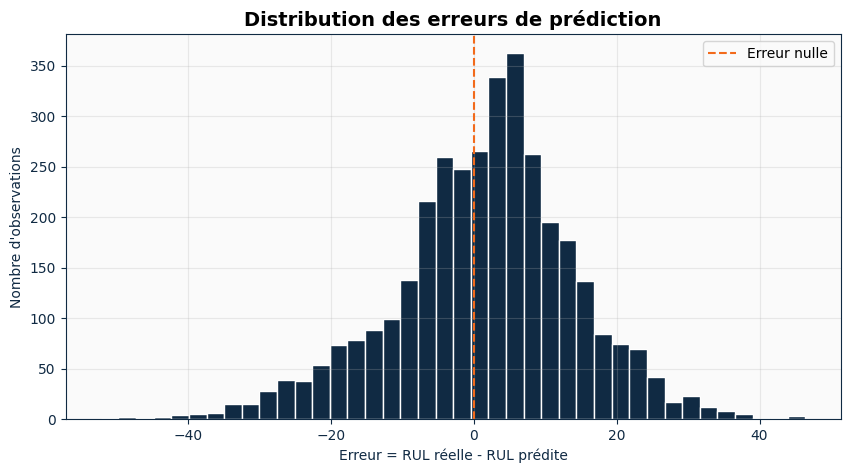

In [23]:
evaluation_df = pd.DataFrame({
    "RUL_reelle": y_val,
    "RUL_predite": y_val_pred_clipped,
    "erreur": y_val - y_val_pred_clipped,
    "erreur_absolue": np.abs(y_val - y_val_pred_clipped)
})

plt.figure(figsize=(7, 7))
plt.scatter(evaluation_df["RUL_reelle"], evaluation_df["RUL_predite"], alpha=0.35, color=INNO_TEAL)
plt.plot([0, RUL_MAX], [0, RUL_MAX], "--", color=INNO_ORANGE, label="Prédiction parfaite")
plt.title(f"RUL réelle vs RUL prédite — {best_model_name}")
plt.xlabel("RUL réelle")
plt.ylabel("RUL prédite")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(evaluation_df["erreur"], bins=40, color=INNO_DARK, edgecolor="white")
plt.axvline(0, color=INNO_ORANGE, linestyle="--", label="Erreur nulle")
plt.title("Distribution des erreurs de prédiction")
plt.xlabel("Erreur = RUL réelle - RUL prédite")
plt.ylabel("Nombre d'observations")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

Le nuage “RUL réelle vs RUL prédite” permet de vérifier si les prédictions suivent bien la diagonale idéale.  
La distribution des erreurs permet, elle, d’identifier les zones où le modèle se trompe davantage. En maintenance, ces erreurs doivent être surveillées surtout lorsque la RUL est faible, car c’est là que la décision d’intervention est la plus critique.

---
## 15. Traduction métier : seuils de décision maintenance

La prédiction RUL devient utile lorsqu’elle est reliée à une action.

On propose trois niveaux de décision :

| RUL prédite | Niveau de risque | Décision |
|---:|---|---|
| RUL > 60 cycles | Faible | Production autorisée |
| 30 < RUL ≤ 60 cycles | Modéré | Surveillance renforcée |
| RUL ≤ 30 cycles | Élevé | Maintenance préventive à planifier |

Ces seuils peuvent être ajustés selon la criticité des équipements InnoMoov.

,RUL_reelle,RUL_predite,erreur,erreur_absolue,niveau_risque,decision
0,125,121.783363,3.216637,3.216637,Risque faible,Production autorisée
1,125,118.966881,6.033119,6.033119,Risque faible,Production autorisée
2,125,120.922401,4.077599,4.077599,Risque faible,Production autorisée
3,125,118.811630,6.188370,6.188370,Risque faible,Production autorisée
4,125,115.046021,9.953979,9.953979,Risque faible,Production autorisée
5,125,116.116608,8.883392,8.883392,Risque faible,Production autorisée
6,125,119.809616,5.190384,5.190384,Risque faible,Production autorisée
7,125,122.221069,2.778931,2.778931,Risque faible,Production autorisée
8,125,122.812347,2.187653,2.187653,Risque faible,Production autorisée
9,125,123.339249,1.660751,1.660751,Risque faible,Production autorisée


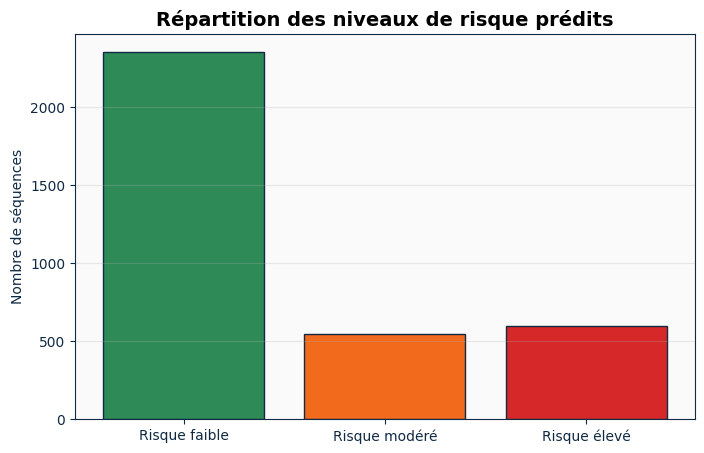

In [24]:
def maintenance_decision(rul_pred):
    if rul_pred <= 30:
        return "Risque élevé", "Maintenance préventive à planifier"
    elif rul_pred <= 60:
        return "Risque modéré", "Surveillance renforcée"
    else:
        return "Risque faible", "Production autorisée"

evaluation_df["niveau_risque"], evaluation_df["decision"] = zip(
    *evaluation_df["RUL_predite"].apply(maintenance_decision)
)

display(evaluation_df.head(10))

risk_counts = evaluation_df["niveau_risque"].value_counts().reindex(
    ["Risque faible", "Risque modéré", "Risque élevé"]
)

plt.figure(figsize=(8, 5))
plt.bar(
    risk_counts.index,
    risk_counts.values,
    color=[INNO_GREEN, INNO_ORANGE, INNO_RED],
    edgecolor=INNO_DARK
)
plt.title("Répartition des niveaux de risque prédits")
plt.ylabel("Nombre de séquences")
plt.grid(axis="y", alpha=0.25)
plt.show()

La prédiction est traduite en trois niveaux de risque : faible, modéré et élevé.  
C’est cette traduction qui rend le modèle utilisable par les équipes InnoMoov : au lieu d’afficher seulement une valeur numérique, le dashboard peut proposer une action claire, comme autoriser la production, renforcer la surveillance ou planifier une maintenance préventive.

---
## 16. Simulation de prédiction pour une machine

Cette cellule montre comment exploiter le modèle sur une séquence récente d’un moteur.  
Dans un déploiement InnoMoov, cette séquence viendrait des capteurs remontés via OPC UA / MQTT puis contextualisés dans le MES.

In [25]:
def predict_rul_for_engine(engine_id, df_scaled, feature_cols, model, sequence_length=30, model_name="CNN 1D"):
    engine_data = df_scaled[df_scaled["engine_id"] == engine_id].sort_values("cycle")

    if len(engine_data) < sequence_length:
        raise ValueError(f"Le moteur {engine_id} n'a pas assez de cycles pour créer une séquence.")

    last_sequence = engine_data[feature_cols].values[-sequence_length:]
    X_input = np.expand_dims(last_sequence, axis=0)

    if model_name == "MLP baseline":
        X_input = X_input.reshape(1, -1)

    rul_pred = float(model.predict(X_input, verbose=0).flatten()[0])
    rul_pred = float(np.clip(rul_pred, 0, RUL_MAX))

    risk_level, decision = maintenance_decision(rul_pred)

    return {
        "engine_id": engine_id,
        "RUL_predite": round(rul_pred, 2),
        "niveau_risque": risk_level,
        "decision": decision
    }

sample_engine = int(val_data_scaled["engine_id"].iloc[0])
prediction_example = predict_rul_for_engine(
    sample_engine,
    val_data_scaled,
    feature_cols,
    best_model,
    sequence_length=SEQUENCE_LENGTH,
    model_name=best_model_name
)

prediction_example

{'engine_id': 1,
 'RUL_predite': 8.46,
 'niveau_risque': 'Risque élevé',
 'decision': 'Maintenance préventive à planifier'}

La prédiction est traduite en trois niveaux de risque : faible, modéré et élevé.  
C’est cette traduction qui rend le modèle utilisable par les équipes InnoMoov : au lieu d’afficher seulement une valeur numérique, le dashboard peut proposer une action claire, comme autoriser la production, renforcer la surveillance ou planifier une maintenance préventive.

---
## 17. Sauvegarde du modèle et des métadonnées

On sauvegarde :

- le modèle Keras ;
- le scaler ;
- les variables utilisées ;
- les paramètres de séquence ;
- les seuils de décision.

Ces fichiers pourront ensuite être réutilisés dans une application Streamlit ou dans un service API.

In [26]:
# Sauvegarde du modèle
model_filename = "innomoov_best_rul_model.keras"
model_path = MODELS_PATH / model_filename
best_model.save(model_path)

metadata = {
    "project": "InnoMoov",
    "solution": "Maintenance prédictive par prédiction de RUL",
    "dataset": DATASET_ID,
    "best_model_name": best_model_name,
    "sequence_length": SEQUENCE_LENGTH,
    "rul_max": RUL_MAX,
    "feature_cols": feature_cols,
    "drop_sensors": drop_sensors,
    "metrics": {
        "mae": float(final_mae),
        "rmse": float(final_rmse),
        "r2": float(final_r2)
    },
    "decision_thresholds": {
        "faible": "RUL > 60",
        "modere": "30 < RUL <= 60",
        "eleve": "RUL <= 30"
    }
}

metadata_path = MODELS_PATH / "innomoov_rul_model_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("Modèle sauvegardé :", model_path)
print("Métadonnées sauvegardées :", metadata_path)
print("Scaler sauvegardé :", scaler_path)

Modèle sauvegardé : c:\Users\ghood\Desktop\MaintenancePredictive_Moteurs\models\innomoov_best_rul_model.keras
Métadonnées sauvegardées : c:\Users\ghood\Desktop\MaintenancePredictive_Moteurs\models\innomoov_rul_model_metadata.json
Scaler sauvegardé : c:\Users\ghood\Desktop\MaintenancePredictive_Moteurs\models\innomoov_rul_scaler.joblib


La sauvegarde du modèle, du scaler et des métadonnées rend la solution réutilisable hors du notebook.  
C’est une étape importante pour passer d’une expérimentation data science à un prototype industriel : les fichiers générés pourront alimenter une application Streamlit, une API ou un dashboard maintenance InnoMoov.

---
## 18. De la donnée capteur à la décision : l’IA GRU estime la RUL et aide InnoMoov à anticiper les interventions de maintenance.
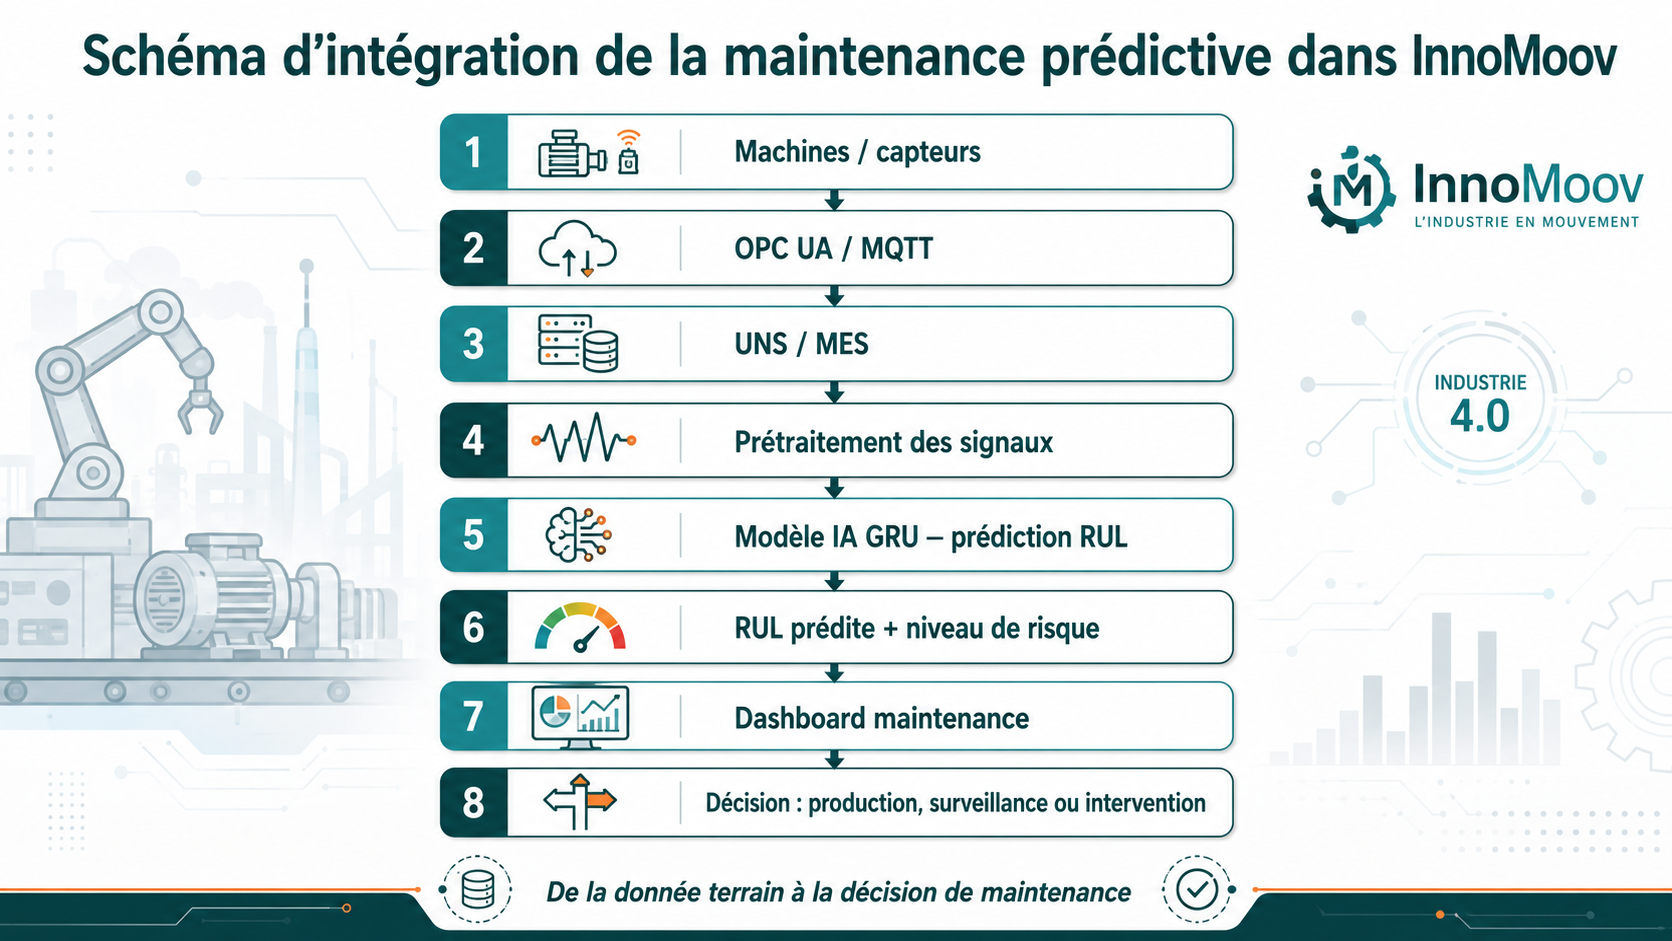

---

## Conclusion

Cette solution IA permet à InnoMoov d’aller au-delà d’une simple détection de panne.  
Elle estime la durée de vie restante d’un équipement critique, ce qui permet d’anticiper les dégradations, de prioriser les interventions et d’améliorer la disponibilité industrielle.

Dans l’exécution réalisée, le **GRU** est le modèle le plus performant. Avec une **MAE d’environ 10 cycles** et un **R² de 0,9044**, il fournit une estimation exploitable de la RUL. Cette performance est suffisante pour construire un premier prototype de dashboard maintenance, à condition de conserver une validation métier par les équipes terrain.

Le modèle transforme les données capteurs en décisions concrètes :

- **RUL élevée** : production autorisée ;
- **RUL intermédiaire** : surveillance renforcée ;
- **RUL faible** : maintenance préventive.

Cette approche s’inscrit pleinement dans une logique **Industrie 4.0**, en reliant capteurs, MES, données temps réel et intelligence artificielle. Pour InnoMoov, elle représente une étape importante vers une maintenance prédictive réellement opérationnelle.